# 10장 실습 ② — 시계열 예측

**Keras 3 판**

파형에서 다음 값을 맞힙니다.
**기준선을 먼저 재는 것**부터 시작합니다. (7장 §7.2)

## 10.0 준비

In [1]:
try:
    import dlbook
except ImportError:
    !pip install -q "dlbook @ git+https://github.com/dhrim/deep-learning-in-one-semester.git"
    import dlbook

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import dlbook
from dlbook import data, metrics, plot

dlbook.set_seed(42)
plot.use_korean()
print(dlbook.versions())

{'python': '3.12.3', 'numpy': '2.1.3', 'keras': '3.15.1', 'tensorflow': '2.21.0', 'torch': '-', 'keras_backend': 'tensorflow'}


## 10.1 실험대 — 파형에서 다음 값

**기준선을 먼저 잽니다.** 아무것도 안 하는 모델의 성적을 모르면
모델의 성적을 읽을 수 없습니다.

구분            개수  입력 shape
train       2800  (40, 1)
val          600  (40, 1)
test         600  (40, 1)


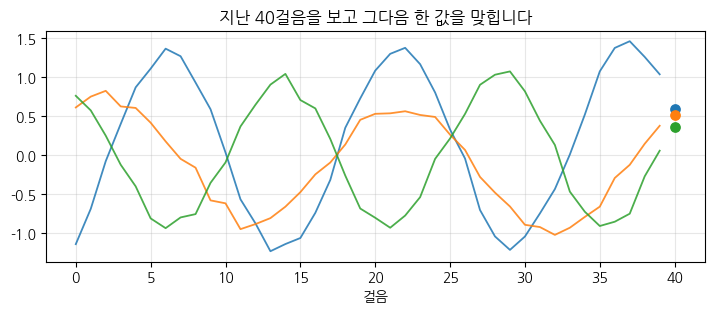

ch10_forecast_baseline_mae = 0.2885
기준선 — '마지막 값을 그대로 답한다' MAE 0.2885
→ 앞으로 나오는 MAE는 이 값과 견주어 읽으십시오.


In [3]:
# 파형에서 다음 값 맞히기. 주기·진폭·위상이 표본마다 다르다.
x, y = data.sine_series(4000, length=40, seed=42)
s = data.split(x, y, val_ratio=0.15, test_ratio=0.15, seed=42)
print(s.summary())

fig, ax = plt.subplots(figsize=(8.5, 3.0))
for k in range(3):
    ax.plot(x[k, :, 0], lw=1.3, alpha=0.85)
    ax.scatter([40], [y[k]], s=45, zorder=5)
ax.set_xlabel("걸음"); ax.grid(alpha=0.3)
ax.set_title("지난 40걸음을 보고 그다음 한 값을 맞힙니다")
plt.show()

# ★ 기준선을 먼저 잽니다 (7장 §7.2)
baseline = metrics.mae(s.y_test, s.x_test[:, -1, 0])
dlbook.record("ch10_forecast_baseline_mae", baseline)
print(f"기준선 — '마지막 값을 그대로 답한다' MAE {baseline:.4f}")
print("→ 앞으로 나오는 MAE는 이 값과 견주어 읽으십시오.")

## 10.2 학습 함수 — 여기만 판마다 다릅니다

**PyTorch 판에 `Recurrent` 래퍼가 하나 더 있는 것**에 주목하십시오.
PyTorch의 순환 층은 (출력 전체, 마지막 상태)를 돌려주므로,
Keras의 기본 동작(마지막 것만)과 맞추려면 감싸야 합니다.

In [4]:
import keras
from keras import layers

def _recurrent(kind, units=32):
    return {"rnn": layers.SimpleRNN, "lstm": layers.LSTM,
            "gru": layers.GRU}[kind](units)

def train_seq(kind, sp, length, lr=0.001, seed=42, epochs=25):
    """분류: 표시된 자리의 부호 맞히기. (시험 정확도)

    이 함수 하나만 판마다 다르다. 아래의 모든 실험 셀은 세 판이 같다.
    """
    dlbook.set_seed(seed)
    ls = [layers.Input(shape=(length, 2))]
    if kind == "dnn":
        ls += [layers.Flatten(), layers.Dense(64, activation="relu")]
    else:
        ls += [_recurrent(kind)]
    ls += [layers.Dense(2, activation="softmax")]
    m = keras.Sequential(ls)
    m.compile(optimizer=keras.optimizers.Adam(lr),
              loss="sparse_categorical_crossentropy")
    m.fit(sp.x_train, sp.y_train, epochs=dlbook.smoke.epochs(epochs),
          batch_size=64, verbose=0)
    return metrics.accuracy(sp.y_test, m.predict(sp.x_test, verbose=0).argmax(1))

def train_forecast(kind, sp, lr=0.003, seed=42, epochs=30):
    """회귀: 다음 값 맞히기. (MAE, 파라미터 수)"""
    dlbook.set_seed(seed)
    ls = [layers.Input(shape=(sp.x_train.shape[1], 1))]
    if kind == "dnn":
        ls += [layers.Flatten(), layers.Dense(64, activation="relu")]
    else:
        ls += [_recurrent(kind)]
    ls += [layers.Dense(1)]
    m = keras.Sequential(ls)
    m.compile(optimizer=keras.optimizers.Adam(lr), loss="mse")
    m.fit(sp.x_train, sp.y_train, validation_data=(sp.x_val, sp.y_val),
          epochs=dlbook.smoke.epochs(epochs), batch_size=64, verbose=0)
    pred = m.predict(sp.x_test, verbose=0).reshape(-1)
    return metrics.mae(sp.y_test, pred), m.count_params()

## 10.3 네 가지 구조를 나란히

In [5]:
print(f"{'모델':<10}{'파라미터':>12}{'MAE':>10}")
print(f"{'(기준선)':<10}{'-':>12}{baseline:>10.4f}")
for kind in ("dnn", "rnn", "lstm", "gru"):
    mae, n_params = train_forecast(kind, s)
    print(f"{kind:<10}{n_params:>12,}{mae:>10.4f}")
    dlbook.record(f"ch10_forecast_{kind}_mae", mae)

print()
print("→ SimpleRNN이 DNN과 같은 성능을 **파라미터 절반 이하**로 냅니다.")
print("→ LSTM·GRU가 11%쯤 더 낫습니다. 이 과제에서는 게이트가 도움이 됐습니다.")

모델                파라미터       MAE
(기준선)                -    0.2885


dnn              2,689    0.0991
ch10_forecast_dnn_mae = 0.0991


rnn              1,121    0.0987
ch10_forecast_rnn_mae = 0.0987


lstm             4,385    0.0877
ch10_forecast_lstm_mae = 0.0877


gru              3,393    0.0868
ch10_forecast_gru_mae = 0.0868

→ SimpleRNN이 DNN과 같은 성능을 **파라미터 절반 이하**로 냅니다.
→ LSTM·GRU가 11%쯤 더 낫습니다. 이 과제에서는 게이트가 도움이 됐습니다.


## 정리

- **기준선을 먼저 재십시오.** 시계열에서 그것은 *"마지막 값을 그대로 답하기"*
  입니다. 이 기준선을 못 넘는 모델이 놀랄 만큼 흔합니다.
- **SimpleRNN이 DNN과 같은 성능을 파라미터 절반 이하로** 냅니다.
  8장에서 CNN이 그랬던 것과 같은 이유 — **파라미터 공유**입니다.
- LSTM·GRU가 11%쯤 낫습니다. 이 과제에서는 게이트가 도움이 됐습니다.

### 연습

1. 예측 구간(`horizon`)을 1 → 5 → 10으로 늘리십시오. 기준선과의 차이가
   어떻게 변합니까.
2. 잡음(`noise`)을 키우면 어떻게 됩니까. 어느 지점에서 기준선을 못 넘습니까.
3. **하나의 긴 시계열**을 잘라 쓰는 경우로 바꿔 보십시오.
   그때는 **반드시 시간 순서로** 나눠야 합니다. (4장 §4.2)